In [38]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import h5py
from scipy.ndimage import map_coordinates

In [2]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [3]:
whamhdr

 [astropy.io.fits.verify]


SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [4]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912.fits'
whamdat1 = fits.getdata(fn) 
whamhdr1 = fits.getheader(fn)

In [5]:
whamhdr1

SIMPLE  =                    T / Written by IDL:  Tue Sep 12 13:21:42 2017      
BITPIX  =                    8 /                                                
NAXIS   =                    0 /                                                
EXTEND  =                    T / File contains extensions                       
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
COMMENT WHAM Sky Survey - Release DR1 (161116)                                  
COMMENT                                                                         
COMMENT REFERENCES:                                                             
COMMENT                                                                         
COMMENT Northern Sky Survey - Haffner, Reynolds, Tufte, Madsen, Jaehnig, &      
COMMENT Percival. 2003, ApJS

In [31]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

Velocity range: -169.1 to 157.3 km/s


In [32]:
#masking for local velocities 
velMask = (velAxis >= -80) & (velAxis <= 80)
velMask.sum()

np.int64(79)

In [33]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


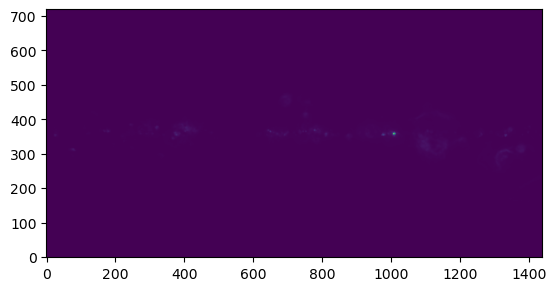

In [34]:
plt.imshow(whamIntegrated, origin = 'lower')

In [35]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

NaN count: 65383544
Zero count: 0
Data range: -0.0994 to 77.8963
Integrated map range: -1.3497 to 4417.2949


In [36]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

Channels selected: 79
Velocity range used: -79.9 to 78.2 km/s


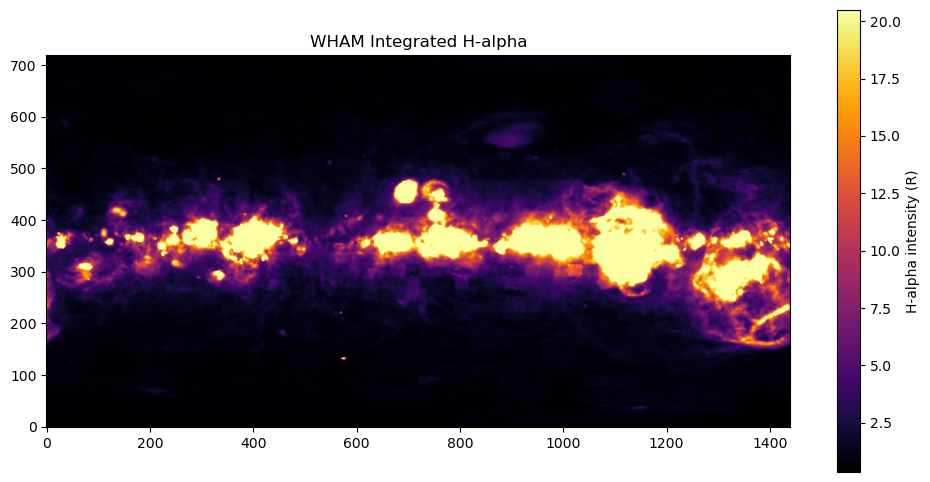

In [37]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

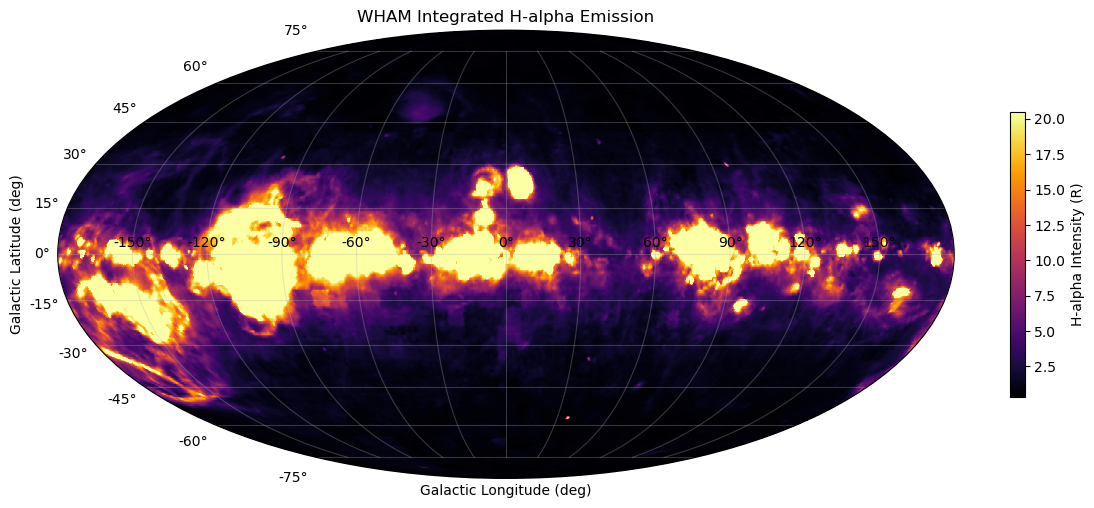

In [39]:
import matplotlib.pyplot as plt
import numpy as np

lon = np.linspace(180, -180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

# now move this into the DRAGONS notebook